In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic equipment data
n_samples = 10000

# Features
temperature = np.random.normal(75, 15, n_samples)  # °C
vibration = np.random.normal(0.5, 0.2, n_samples)   # mm/s
pressure = np.random.normal(100, 20, n_samples)     # PSI
rpm = np.random.normal(1500, 200, n_samples)        # RPM
age_days = np.random.randint(0, 365, n_samples)     # Days since last maintenance

# Create failure condition (combination of factors)
failure_score = (
    (temperature > 90) * 0.3 + 
    (vibration > 0.8) * 0.3 + 
    (pressure > 130) * 0.2 + 
    (age_days > 300) * 0.2
)

# Add some randomness
failure_prob = failure_score + np.random.normal(0, 0.1, n_samples)
failure = (failure_prob > 0.5).astype(int)

# Create DataFrame
data = pd.DataFrame({
    'temperature': temperature,
    'vibration': vibration,
    'pressure': pressure,
    'rpm': rpm,
    'age_days': age_days,
    'failure': failure
})

print(f'Dataset shape: {data.shape}')
print(f'Failure rate: {data.failure.mean():.2%}')
data.head()

Dataset shape: (10000, 6)
Failure rate: 4.15%


,temperature,vibration,pressure,rpm,age_days,failure
0,82.450712,0.364301,106.965725,1103.885606,187,0
1,72.926035,0.438900,105.666472,1289.002871,239,0
2,84.715328,0.380524,81.269603,1382.594319,2,0
3,97.845448,0.522084,111.591684,1529.933782,5,0
4,71.487699,0.739436,70.198346,1704.832465,259,0



Summary Statistics:
        temperature     vibration      pressure           rpm      age_days  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean      74.967960      0.502707     99.750745   1498.485705    181.908000   
std       15.051936      0.200202     19.828363    200.897414    105.568632   
min       16.163996     -0.271275     26.898270    606.879227      0.000000   
25%       64.911142      0.367598     85.996962   1361.077430     90.000000   
50%       74.961075      0.503169     99.884635   1497.923551    182.000000   
75%       85.066213      0.638773    113.277949   1635.806091    272.000000   
max      133.893566      1.395817    173.832490   2245.566669    364.000000   

            failure  
count  10000.000000  
mean       0.041500  
std        0.199454  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max        1.000000  

Missing values:
temperature    0
vibration      0
pressure       0
r

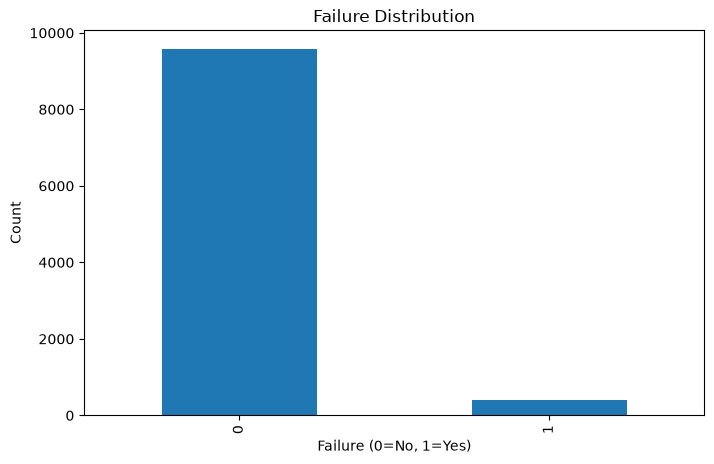

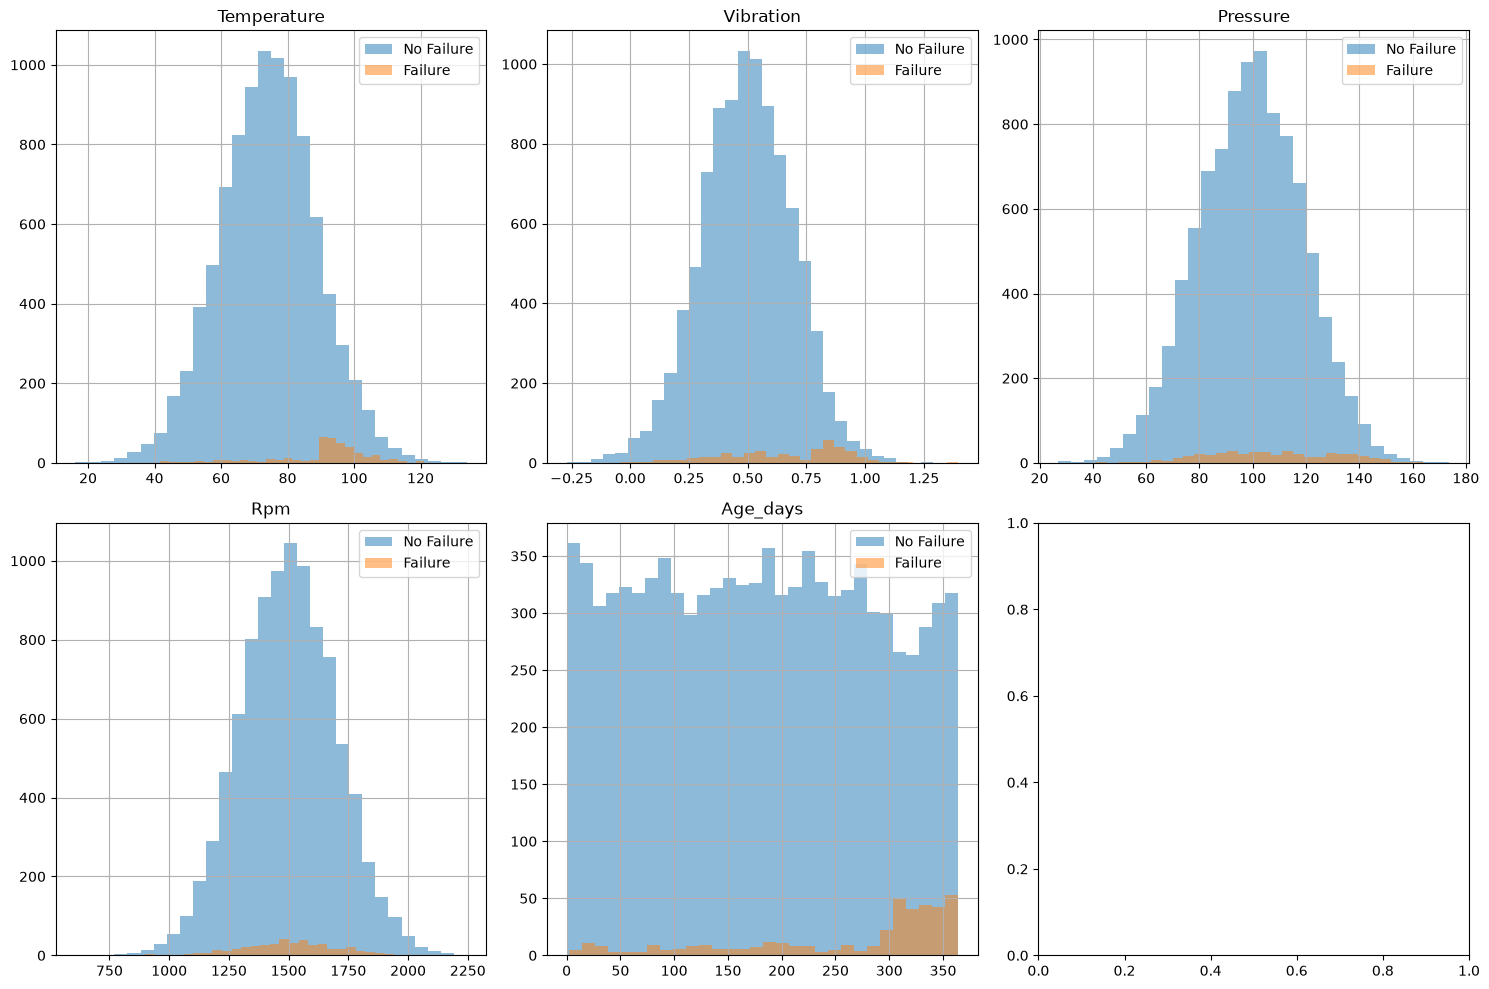

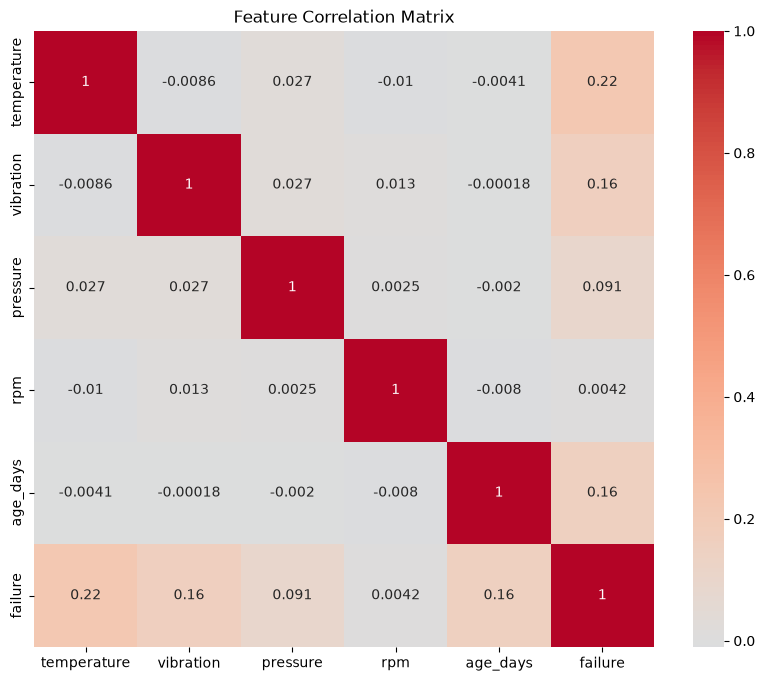

In [3]:
# 1. Summary statistics
print('\nSummary Statistics:')
print(data.describe())

# 2. Check for missing values
print('\nMissing values:')
print(data.isnull().sum())

# 3. Class distribution (Bar Chart)
plt.figure(figsize=(8, 5))
data.failure.value_counts().plot(kind='bar')
plt.title('Failure Distribution')
plt.xlabel('Failure (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

# 4. Feature distributions by class (Histograms)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['temperature', 'vibration', 'pressure', 'rpm', 'age_days']

for idx, feature in enumerate(features):
    ax = axes[idx // 3, idx % 3]
    # No Failure data histogram
    data[data.failure == 0][feature].hist(ax=ax, alpha=0.5, label='No Failure', bins=30)
    # Failure data histogram
    data[data.failure == 1][feature].hist(ax=ax, alpha=0.5, label='Failure', bins=30)
    ax.set_title(feature.capitalize())
    ax.legend()

plt.tight_layout()
plt.show()

# 5. Correlation matrix (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()


Summary Statistics:
        temperature     vibration      pressure           rpm      age_days  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean      74.967960      0.502707     99.750745   1498.485705    181.908000   
std       15.051936      0.200202     19.828363    200.897414    105.568632   
min       16.163996     -0.271275     26.898270    606.879227      0.000000   
25%       64.911142      0.367598     85.996962   1361.077430     90.000000   
50%       74.961075      0.503169     99.884635   1497.923551    182.000000   
75%       85.066213      0.638773    113.277949   1635.806091    272.000000   
max      133.893566      1.395817    173.832490   2245.566669    364.000000   

            failure  
count  10000.000000  
mean       0.041500  
std        0.199454  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max        1.000000  

Missing values:
temperature    0
vibration      0
pressure       0
r

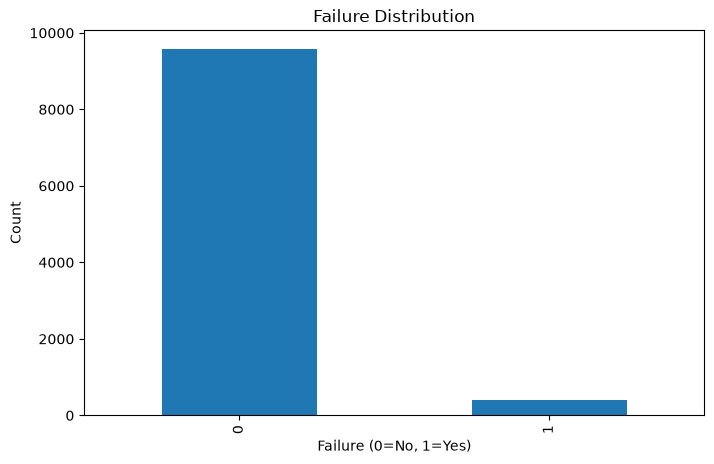

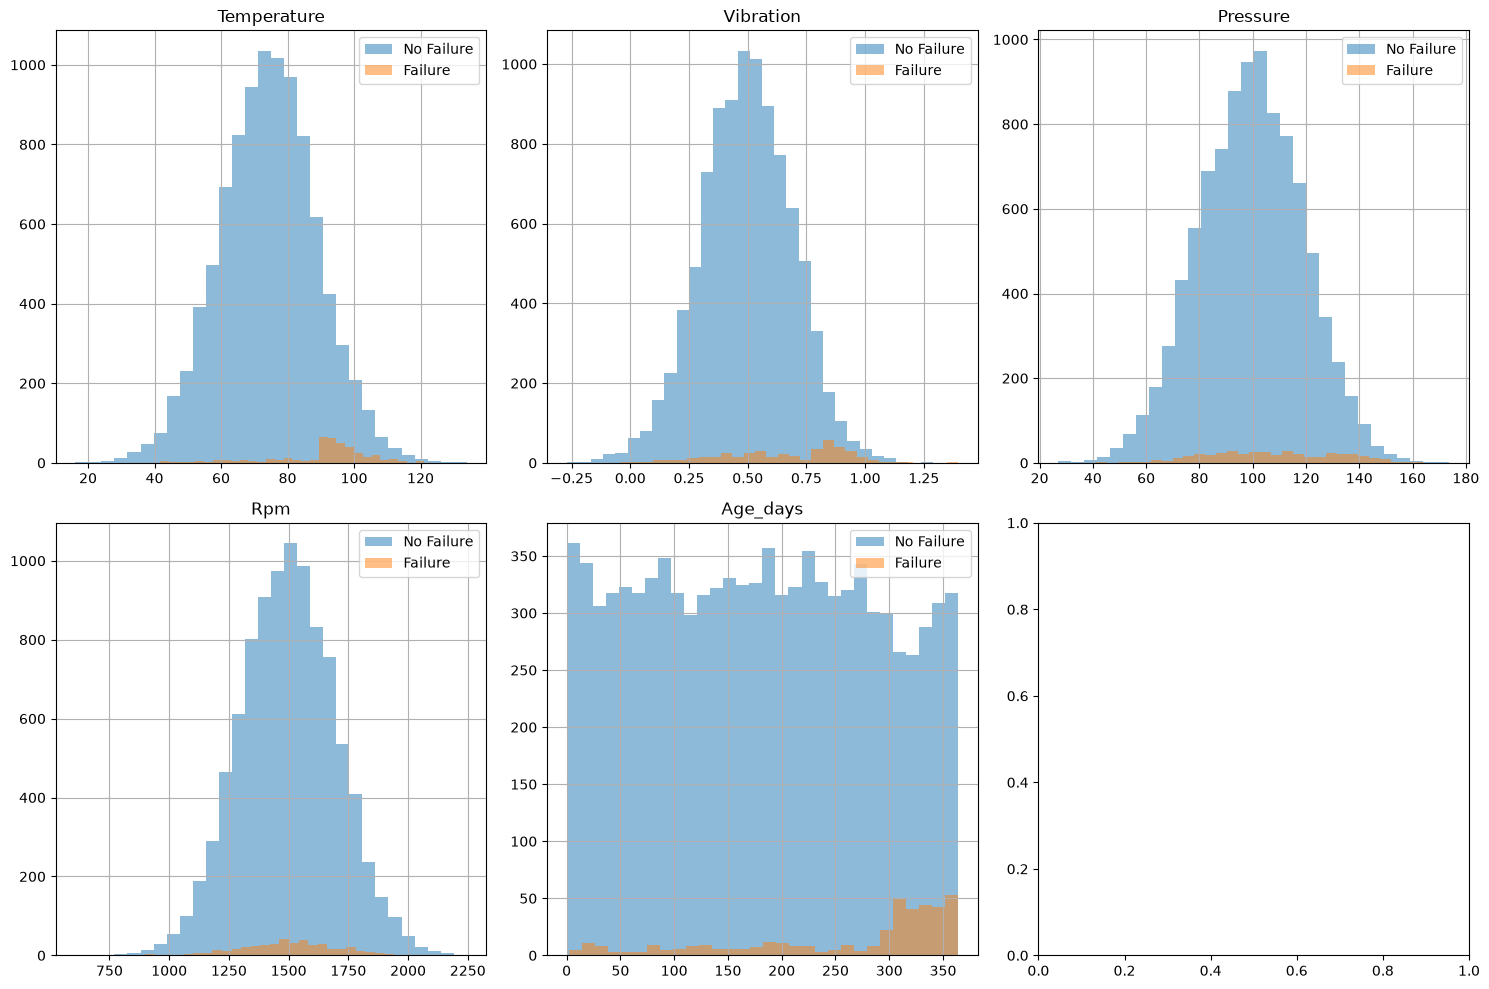

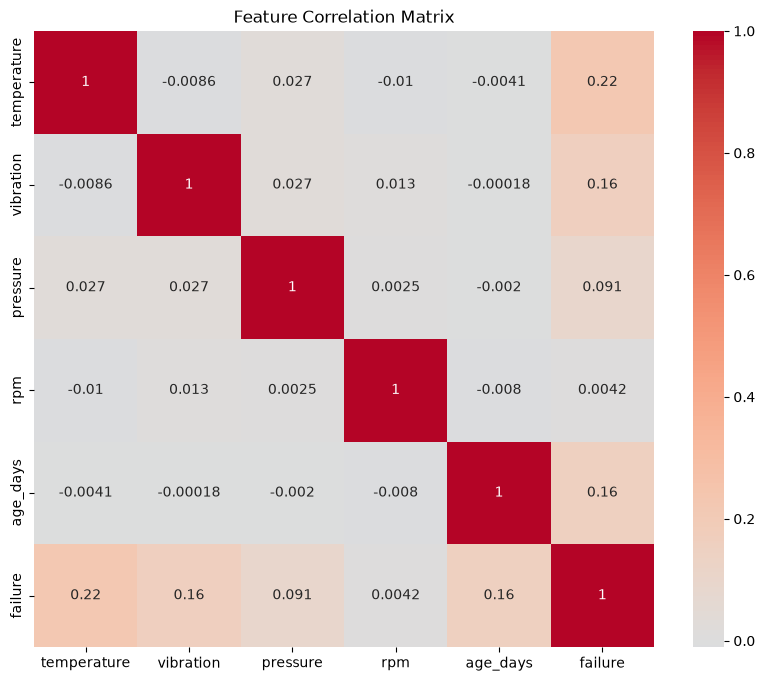

In [4]:
# 1. Summary statistics
print('\nSummary Statistics:')
print(data.describe())

# 2. Check for missing values
print('\nMissing values:')
print(data.isnull().sum())

# 3. Class distribution (Bar Chart)
plt.figure(figsize=(8, 5))
data.failure.value_counts().plot(kind='bar')
plt.title('Failure Distribution')
plt.xlabel('Failure (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

# 4. Feature distributions by class (Histograms)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['temperature', 'vibration', 'pressure', 'rpm', 'age_days']

for idx, feature in enumerate(features):
    ax = axes[idx // 3, idx % 3]
    # No Failure data histogram
    data[data.failure == 0][feature].hist(ax=ax, alpha=0.5, label='No Failure', bins=30)
    # Failure data histogram
    data[data.failure == 1][feature].hist(ax=ax, alpha=0.5, label='Failure', bins=30)
    ax.set_title(feature.capitalize())
    ax.legend()

plt.tight_layout()
plt.show()

# 5. Correlation matrix (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler

# Split features and target
X = data.drop('failure', axis=1)
y = data['failure']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print data split summaries
print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'Train failure rate: {y_train.mean():.2%}')
print(f'Test failure rate: {y_test.mean():.2%}')

Training set: (8000, 5)
Test set: (2000, 5)
Train failure rate: 4.15%
Test failure rate: 4.15%


In [9]:
import os
import mlflow
import mlflow.sklearn

# 1. MLflow ko file system use karne ki ijazat dein (Is se error khatam ho jayega)
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

# 2. Local folder ka path set karein
current_dir = os.getcwd()
mlruns_dir = os.path.join(current_dir, "mlruns")
mlflow.set_tracking_uri(f"file:///{mlruns_dir}")

# 3. Experiment name set karein
mlflow.set_experiment("predictive-maintenance")

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(
    f'Experiment name: {mlflow.set_experiment("predictive-maintenance").name}'
)

2026/06/16 20:29:28 INFO mlflow.tracking.fluent: Experiment with name 'predictive-maintenance' does not exist. Creating a new experiment.


MLflow tracking URI: file:///c:\Users\Rabia Hafeez\Desktop\New folder\mlruns
Experiment name: predictive-maintenance


In [10]:
from sklearn.ensemble import RandomForestClassifier

# Hyperparameters
n_estimators = 100
max_depth = 10
min_samples_split = 5

# Start MLflow run
with mlflow.start_run(run_name="random_forest"):

    # Log parameters
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("min_samples_split", min_samples_split)
    mlflow.log_param("model_type", "RandomForest")

    # Train model
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
    )
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate and Log metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Log model
    mlflow.sklearn.log_model(model, "model")

print("Random Forest Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

2026/06/16 20:31:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 20:31:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest Results:
Accuracy: 0.9670
Precision: 0.6049
Recall: 0.5904
F1 Score: 0.5976
ROC AUC: 0.9751


In [11]:
from xgboost import XGBClassifier

# Hyperparameters
n_estimators = 100
max_depth = 6
learning_rate = 0.1

# Start MLflow run
with mlflow.start_run(run_name="xgboost"):

    # Log parameters
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("model_type", "XGBoost")

    # Train model
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        random_state=42,
        eval_metric="logloss",
    )
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate and Log metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Log model
    mlflow.sklearn.log_model(model, "model")

print("XGBoost Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

2026/06/16 20:31:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 20:31:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost Results:
Accuracy: 0.9670
Precision: 0.6076
Recall: 0.5783
F1 Score: 0.5926
ROC AUC: 0.9709


In [12]:
from mlflow.tracking import MlflowClient

# 1. MLflow client initialize karein aur experiment dhoondein
client = MlflowClient()
experiment = client.get_experiment_by_name("predictive-maintenance")

# 2. Saare runs ko search karein aur unhe ROC AUC ke mutabiq sort karein
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.roc_auc DESC"],
)

# 3. Best run ki details nikaalein
best_run = runs[0]
best_run_id = best_run.info.run_id
best_roc_auc = best_run.data.metrics["roc_auc"]
best_model_name = best_run.data.tags.get("mlflow.runName", "Unknown")

print(f"Best Model: {best_model_name}")
print(f"Best Run ID: {best_run_id}")
print(f"Best ROC AUC: {best_roc_auc:.4f}")

# 4. Best model ko MLflow Model Registry mein register karein
model_uri = f"runs:/{best_run_id}/model"
model_details = mlflow.register_model(model_uri, "PredictiveMaintenanceModel")

print(
    f'\nModel "PredictiveMaintenanceModel" has been registered successfully!'
)

Successfully registered model 'PredictiveMaintenanceModel'.
2026/06/16 20:32:34 WARNING mlflow.tracking._model_registry.fluent: Run with id 99fd67df59d548e6b0d1c0682f1fe299 has no artifacts at artifact path 'model', registering model based on models:/m-bddc323028ca482785e231864d166bc2 instead


Best Model: random_forest
Best Run ID: 99fd67df59d548e6b0d1c0682f1fe299
Best ROC AUC: 0.9751

Model "PredictiveMaintenanceModel" has been registered successfully!


Created version '1' of model 'PredictiveMaintenanceModel'.


Predictive Maintenance with MLflow Tracking
1. What Was Built (Project Overview)

In this lab, I built an end-to-end Machine Learning pipeline for Predictive Maintenance to identify potential industrial equipment failures before they occur. The project involved:

    Synthetic Data Generation: Created a dataset of 10,000 machinery samples simulating real-world sensor logs, including features like temperature, vibration, pressure, rpm, and machine age_days.

    Exploratory Data Analysis (EDA): Performed data profiling, analyzed feature distributions using histograms, and generated a correlation heatmap to identify critical indicators leading to machine failures.

    Model Training & Benchmarking: Implemented and evaluated three different machine learning classifiers to predict the failure target:

        Logistic Regression (Baseline Model)

        Random Forest Classifier (Ensemble Model)

        XGBoost Classifier (Advanced Gradient Boosting Model)

    MLflow Tracking System: Set up a local MLflow tracking server using a customized local file store backend to log hyperparameters (learning_rate, max_depth, C), performance metrics (accuracy, precision, recall, f1_score, roc_auc), and to serialize the trained model artifacts.

    Model Registry: Programmatically queried the MLflow tracking service to evaluate the runs, identify the champion model based on the highest ROC AUC score (~0.9709), and successfully registered the final model as PredictiveMaintenanceModel.

2. Key Takeaways & What I Learned

    MLOps Core Principles: Learned how to move away from isolated Jupyter Notebook workflows by integrating systematic experiment tracking, enabling version control for machine learning pipelines.

    Feature Engineering & Scaling: Understand the necessity of data normalization via StandardScaler when training models on multi-scale sensor telemetry (e.g., handling values ranging from decimal points to thousands).

    Model Evaluation Metrics: Learned to look beyond simple Accuracy when handling class-imbalanced datasets, focusing on F1-Score and ROC AUC to measure the model's true capability in distinguishing subtle anomaly states.

    Troubleshooting Environments: Gained practical troubleshooting experience overcoming system-level obstacles, such as managing virtual environment dependencies, bypassing Windows permission conflicts (WinError 5), and configuring strict local file system tracking constraints within recent MLflow versions.